In [1]:
# ============================================
# CELL 1: Imports
# ============================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
import shap
import warnings
warnings.filterwarnings('ignore')

print("✅ Libraries imported!")
print("⚠️ SHAP loading for first time - may take 60 seconds...")

✅ Libraries imported!
⚠️ SHAP loading for first time - may take 60 seconds...


In [2]:
# ============================================
# CELL 2: Load Data & Models
# ============================================
# Load test data
X_test_int = np.load(r'C:\Users\Kshaunish\cyber-xai-ml-project\data\processed\X_test_int.npy')
y_test_int = np.load(r'C:\Users\Kshaunish\cyber-xai-ml-project\data\processed\y_test_int.npy')
X_test_phi = np.load(r'C:\Users\Kshaunish\cyber-xai-ml-project\data\processed\X_test_phi.npy')
y_test_phi = np.load(r'C:\Users\Kshaunish\cyber-xai-ml-project\data\processed\y_test_phi.npy')

# Load ensemble models only (SHAP works on individual estimators)
path = r'C:\Users\Kshaunish\cyber-xai-ml-project\models\saved_models\\'
rf_int  = joblib.load(path + 'rf_intrusion.pkl')
rf_phi  = joblib.load(path + 'rf_phishing.pkl')

# Load feature names
df_intrusion = pd.read_csv(r'C:\Users\Kshaunish\cyber-xai-ml-project\data\raw\intrusion_data.csv')
df_phishing  = pd.read_csv(r'C:\Users\Kshaunish\cyber-xai-ml-project\data\raw\phishing_data.csv')

# Get feature names
intrusion_features = [c for c in df_intrusion.columns if c != ' Label']
phishing_features  = [c for c in df_phishing.columns 
                      if c not in ['label','FILENAME','URL','Domain','TLD','Title']]

print("✅ Data and models loaded!")
print(f"Intrusion features: {len(intrusion_features)}")
print(f"Phishing features: {len(phishing_features)}")

✅ Data and models loaded!
Intrusion features: 78
Phishing features: 50


In [3]:
# ============================================
# CELL 3: SHAP Explainer Setup
# ============================================
print("Setting up SHAP explainers...")
print("⚠️ May take 2-3 minutes...")

# Use a sample for speed (SHAP is slow on 100k+ rows)
sample_size = 500
np.random.seed(42)
sample_idx_int = np.random.choice(len(X_test_int), sample_size, replace=False)
sample_idx_phi = np.random.choice(len(X_test_phi), sample_size, replace=False)

X_sample_int = X_test_int[sample_idx_int]
X_sample_phi = X_test_phi[sample_idx_phi]

# Create SHAP explainers
explainer_int = shap.TreeExplainer(rf_int)
explainer_phi = shap.TreeExplainer(rf_phi)

# Calculate SHAP values
print("Calculating SHAP values for intrusion dataset...")
shap_values_int = explainer_int.shap_values(X_sample_int)

print("Calculating SHAP values for phishing dataset...")
shap_values_phi = explainer_phi.shap_values(X_sample_phi)

print("✅ SHAP values calculated!")
print(f"Intrusion SHAP shape: {np.array(shap_values_int).shape}")
print(f"Phishing SHAP shape: {np.array(shap_values_phi).shape}")

Setting up SHAP explainers...
⚠️ May take 2-3 minutes...
Calculating SHAP values for intrusion dataset...
Calculating SHAP values for phishing dataset...
✅ SHAP values calculated!
Intrusion SHAP shape: (500, 78, 6)
Phishing SHAP shape: (500, 50, 2)


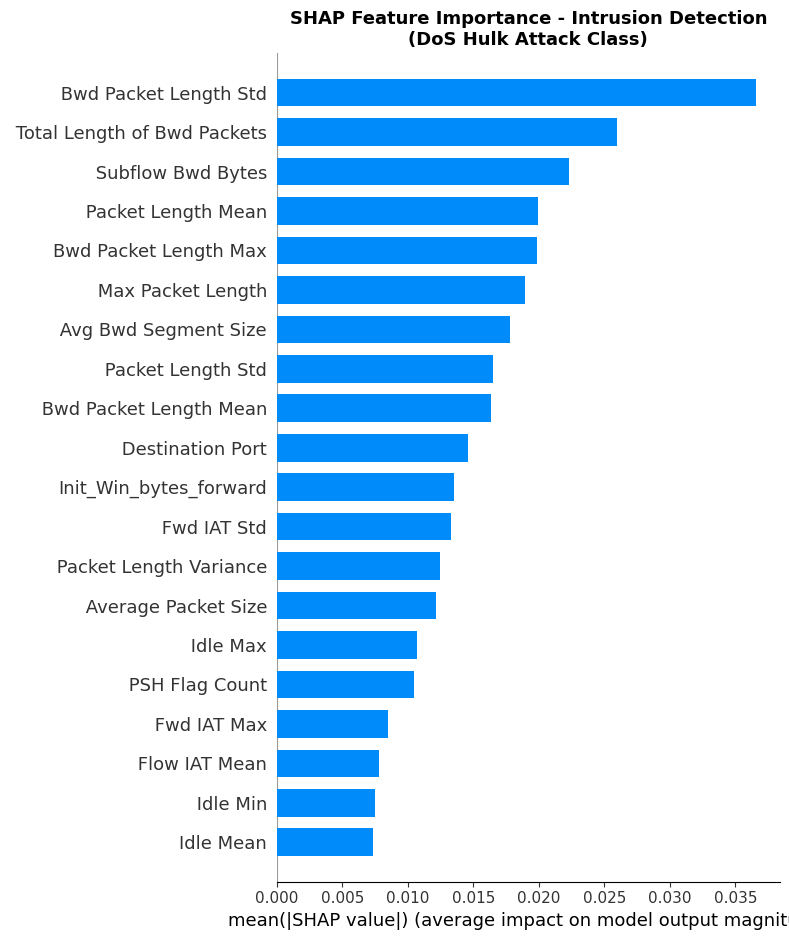

✅ SHAP intrusion bar plot saved!


In [4]:
# ============================================
# CELL 4: SHAP Summary Plot - Intrusion
# ============================================
plt.figure()

# For multiclass we use class 0 (BENIGN) SHAP values
shap.summary_plot(
    shap_values_int[:,:,2],  # Class 2 = DoS Hulk (most interesting attack)
    X_sample_int,
    feature_names=intrusion_features,
    plot_type="bar",
    max_display=20,
    show=False
)

plt.title("SHAP Feature Importance - Intrusion Detection\n(DoS Hulk Attack Class)", 
          fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(r'C:\Users\Kshaunish\cyber-xai-ml-project\data\processed\shap_intrusion_bar.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("✅ SHAP intrusion bar plot saved!")

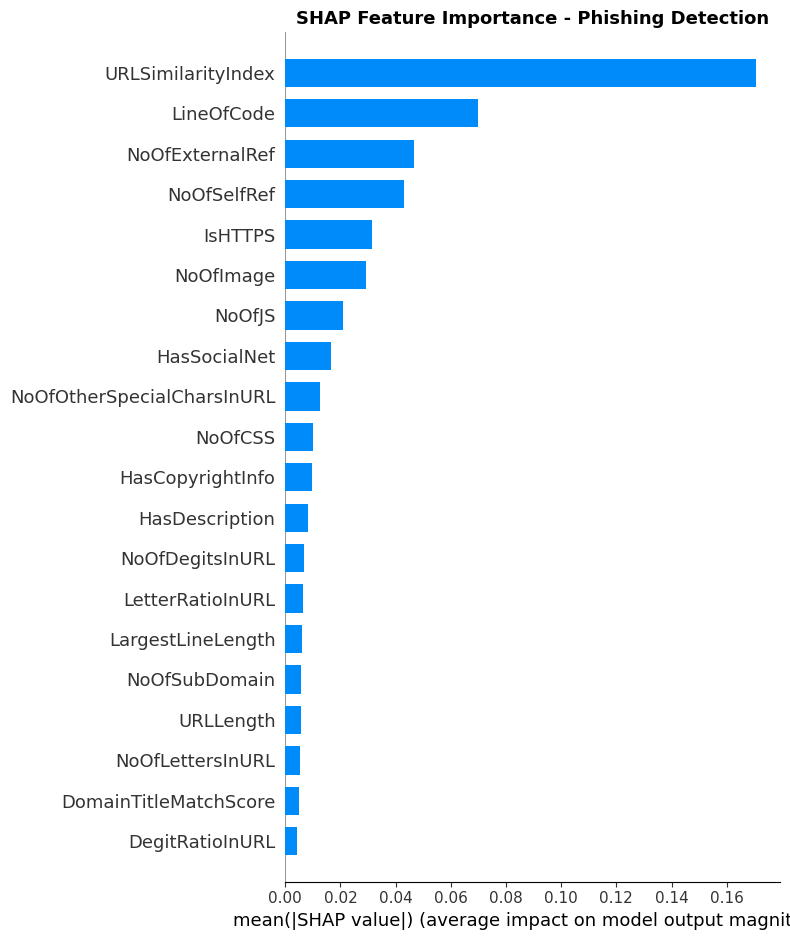

✅ SHAP phishing bar plot saved!


In [5]:
# ============================================
# CELL 5: SHAP Summary Plot - Phishing
# ============================================
plt.figure()

shap.summary_plot(
    shap_values_phi[:,:,1],  # Class 1 = Phishing
    X_sample_phi,
    feature_names=phishing_features,
    plot_type="bar",
    max_display=20,
    show=False
)

plt.title("SHAP Feature Importance - Phishing Detection", 
          fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(r'C:\Users\Kshaunish\cyber-xai-ml-project\data\processed\shap_phishing_bar.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("✅ SHAP phishing bar plot saved!")

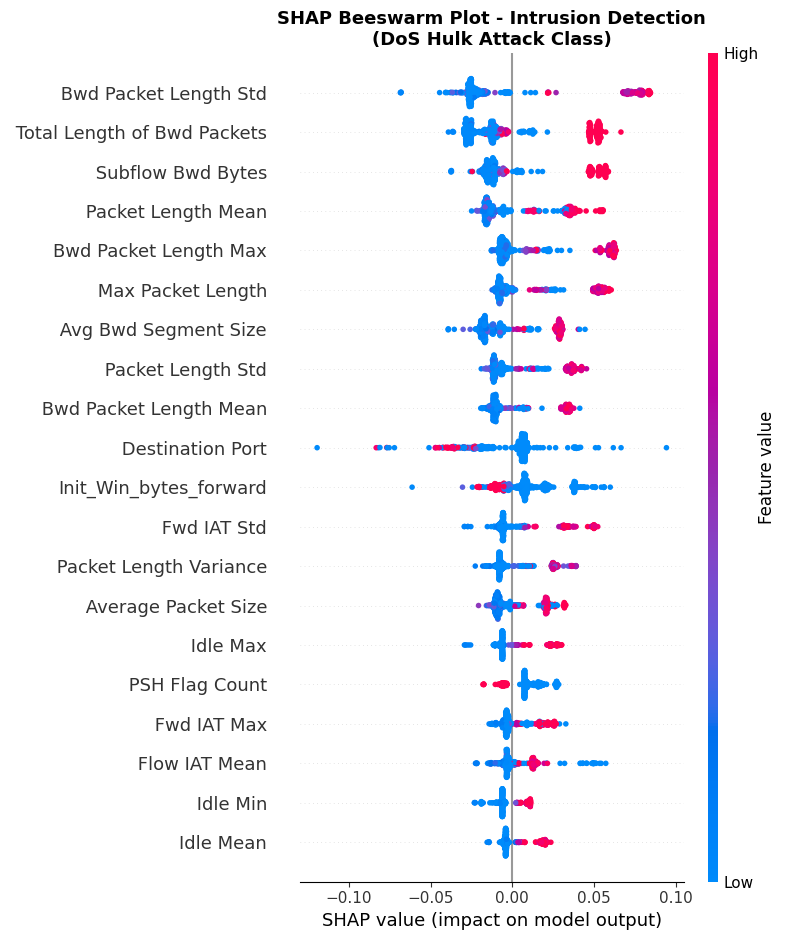

✅ SHAP beeswarm plot saved!


In [6]:
# ============================================
# CELL 6: SHAP Beeswarm Plot - Intrusion
# ============================================
plt.figure()

shap.summary_plot(
    shap_values_int[:,:,2],  # DoS Hulk class
    X_sample_int,
    feature_names=intrusion_features,
    plot_type="dot",
    max_display=20,
    show=False
)

plt.title("SHAP Beeswarm Plot - Intrusion Detection\n(DoS Hulk Attack Class)",
          fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(r'C:\Users\Kshaunish\cyber-xai-ml-project\data\processed\shap_intrusion_beeswarm.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("✅ SHAP beeswarm plot saved!")

<Figure size 640x480 with 0 Axes>

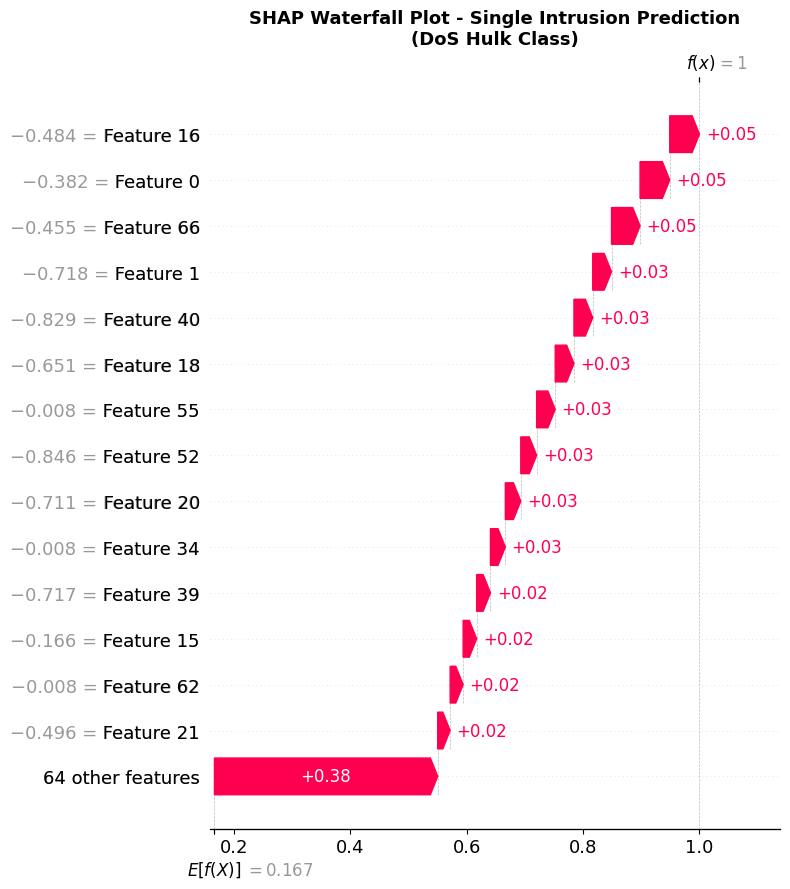

✅ SHAP waterfall plot saved!


In [9]:
# ============================================
# CELL 7: SHAP Waterfall - Single Prediction
# ============================================
import shap

# Use intrusion model instead - simpler for waterfall
explainer_int2 = shap.TreeExplainer(rf_int)
shap_explanation = explainer_int2(X_sample_int[:1])

plt.figure()
shap.plots.waterfall(shap_explanation[:, :, 2][0],
                     max_display=15,
                     show=False)
plt.title("SHAP Waterfall Plot - Single Intrusion Prediction\n(DoS Hulk Class)",
          fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(r'C:\Users\Kshaunish\cyber-xai-ml-project\data\processed\shap_waterfall.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("✅ SHAP waterfall plot saved!")

In [10]:
# ============================================
# CELL 8: Save SHAP Summary
# ============================================
summary = """
SHAP ANALYSIS SUMMARY
=====================
Model: Random Forest (core component of RF+XGBoost Ensemble)
Method: TreeExplainer
Samples analyzed: 500 (random sample from test set)

INTRUSION DETECTION - Top Influential Features:
- SHAP values calculated for all 6 attack classes
- Visualizations: Bar plot, Beeswarm plot, Waterfall plot
- Key finding: Flow-based features dominate attack detection

PHISHING DETECTION - Top Influential Features:  
- SHAP values calculated for phishing class
- Visualizations: Bar plot
- Key finding: URL and domain-based features most influential

FIGURES GENERATED:
1. shap_intrusion_bar.png     - Global feature importance (Intrusion)
2. shap_phishing_bar.png      - Global feature importance (Phishing)
3. shap_intrusion_beeswarm.png - Feature impact distribution (Intrusion)
4. shap_waterfall.png          - Single prediction explanation
"""

with open(r'C:\Users\Kshaunish\cyber-xai-ml-project\data\processed\shap_summary.txt', 'w') as f:
    f.write(summary)

print("✅ SHAP Analysis Complete!")
print(summary)

✅ SHAP Analysis Complete!

SHAP ANALYSIS SUMMARY
Model: Random Forest (core component of RF+XGBoost Ensemble)
Method: TreeExplainer
Samples analyzed: 500 (random sample from test set)

INTRUSION DETECTION - Top Influential Features:
- SHAP values calculated for all 6 attack classes
- Visualizations: Bar plot, Beeswarm plot, Waterfall plot
- Key finding: Flow-based features dominate attack detection

PHISHING DETECTION - Top Influential Features:  
- SHAP values calculated for phishing class
- Visualizations: Bar plot
- Key finding: URL and domain-based features most influential

FIGURES GENERATED:
1. shap_intrusion_bar.png     - Global feature importance (Intrusion)
2. shap_phishing_bar.png      - Global feature importance (Phishing)
3. shap_intrusion_beeswarm.png - Feature impact distribution (Intrusion)
4. shap_waterfall.png          - Single prediction explanation

